In [12]:
import pandas as pd
import random

breeds_sizes = [
    ("Labrador Retriever", "large"),
    ("Golden Retriever", "large"),
    ("German Shepherd", "large"),
    ("Rottweiler", "large"),
    ("Great Dane", "large"),
    ("Doberman Pinscher", "large"),
    ("Siberian Husky", "medium"),
    ("Bulldog", "medium"),
    ("Boxer", "medium"),
    ("Australian Shepherd", "medium"),
    ("Border Collie", "medium"),
    ("Beagle", "small"),
    ("Dachshund", "small"),
    ("Poodle", "small"),
    ("Chihuahua", "small"),
    ("French Bulldog", "small"),
    ("Yorkshire Terrier", "small"),
    ("Shih Tzu", "small"),
    ("Maltese", "small"),
    ("Pomeranian", "small"),
    ("French Griffon", "small")
]

genders = ["Male", "Female"]

num_rows = 500

username_list = random.sample(range(1000, 10000), num_rows)

data = {
    "username": [],
    "pet_breed": [],
    "age": [],
    "size": [],
    "gender": [],
    "latitude": [],
    "longitude": []
}

for i in range(num_rows):
    # Pick a random breed-size pair
    breed, size = random.choice(breeds_sizes)
    
    # Random age between 1 and 15
    age = random.randint(1, 15)
    
    # Random gender
    gender = random.choice(genders)
    
    # Random geographic coordinates in Egypt
    lat = random.uniform(22.0, 31.0)
    lon = random.uniform(25.0, 36.0)
    
    data["username"].append(username_list[i])
    data["pet_breed"].append(breed)
    data["age"].append(age)
    data["size"].append(size)
    data["gender"].append(gender)
    data["latitude"].append(lat)
    data["longitude"].append(lon)

df = pd.DataFrame(data)

df.to_csv("datasetTest500.csv", index=False)

# Show a small sample of the generated data
print("A dataset with 5,000 rows (all located in Egypt) has been generated and saved to 'clean_pet_dataset_5000.csv'.")
print(df.head(10))


A dataset with 5,000 rows (all located in Egypt) has been generated and saved to 'clean_pet_dataset_5000.csv'.
   username            pet_breed  age    size  gender   latitude  longitude
0      4665   Labrador Retriever    8   large    Male  26.191725  29.066214
1      3511  Australian Shepherd    1  medium  Female  25.288634  28.528609
2      1779     Golden Retriever   12   large  Female  29.818229  33.580385
3      9717   Labrador Retriever   14   large  Female  23.612800  25.947063
4      6009               Poodle   12   small  Female  26.776747  35.727428
5      8436                Boxer   14  medium    Male  22.193947  33.241333
6      8376    Yorkshire Terrier    8   small    Male  29.549773  35.604114
7      9547           Pomeranian    3   small  Female  27.118558  28.023329
8      1391            Dachshund    3   small  Female  28.832447  34.600431
9      7986       French Bulldog    9   small    Male  24.816393  31.127506


In [13]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

%matplotlib inline 

In [14]:
# 1) Load your CSV
#    Replace 'petProfiles.csv' with your actual dataset filename/path
df = pd.read_csv('datasetTest500.csv')

print("=== Initial DataFrame Head ===")
print(df.head())

print("\n=== Initial DataFrame Info ===")
print(df.info())

# Quick check for NaN or Inf in the raw DataFrame
print("\nMissing values per column:")
print(df.isna().sum())

print("\nAny infinite values?")
print(np.isinf(df.select_dtypes(include=[np.number])).sum())


=== Initial DataFrame Head ===
   username            pet_breed  age    size  gender   latitude  longitude
0      4665   Labrador Retriever    8   large    Male  26.191725  29.066214
1      3511  Australian Shepherd    1  medium  Female  25.288634  28.528609
2      1779     Golden Retriever   12   large  Female  29.818229  33.580385
3      9717   Labrador Retriever   14   large  Female  23.612800  25.947063
4      6009               Poodle   12   small  Female  26.776747  35.727428

=== Initial DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   500 non-null    int64  
 1   pet_breed  500 non-null    object 
 2   age        500 non-null    int64  
 3   size       500 non-null    object 
 4   gender     500 non-null    object 
 5   latitude   500 non-null    float64
 6   longitude  500 non-null    float64
dtypes: float64(2

In [15]:
# Identify typical categorical columns
categorical_cols = []
if 'pet_breed' in df.columns:
    categorical_cols.append('pet_breed')
if 'size' in df.columns:
    categorical_cols.append('size')
if 'gender' in df.columns:
    categorical_cols.append('gender')

# One-hot encode these to avoid "could not convert string to float" errors
if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols)

# Example: fill missing numeric columns if needed
num_cols = ['age','latitude','longitude']
for col in num_cols:
    if col in df.columns:
        # Fill with mean
        df[col].fillna(df[col].mean(), inplace=True)

# Drop or fix any rows that might still have NaN or Inf
# For safety, let's drop rows with any leftover NaN or Inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("\n=== After dropping/filling missing/infinite values ===")
print(df.info())
print(df.describe())



=== After dropping/filling missing/infinite values ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   username                       500 non-null    int64  
 1   age                            500 non-null    int64  
 2   latitude                       500 non-null    float64
 3   longitude                      500 non-null    float64
 4   pet_breed_Australian Shepherd  500 non-null    bool   
 5   pet_breed_Beagle               500 non-null    bool   
 6   pet_breed_Border Collie        500 non-null    bool   
 7   pet_breed_Boxer                500 non-null    bool   
 8   pet_breed_Bulldog              500 non-null    bool   
 9   pet_breed_Chihuahua            500 non-null    bool   
 10  pet_breed_Dachshund            500 non-null    bool   
 11  pet_breed_Doberman Pinscher    500 non-null    bool   

In [16]:
scaler = StandardScaler()

# If your dataset definitely has these columns
# (If not, adjust or remove them from the list.)
num_cols_to_scale = []
for c in ['latitude','longitude','age']:
    if c in df.columns:
        num_cols_to_scale.append(c)

# Scale them in-place
if num_cols_to_scale:
    df[num_cols_to_scale] = scaler.fit_transform(df[num_cols_to_scale])

print("\n=== After Scaling latitude, longitude, age ===")
print(df[num_cols_to_scale].describe())



=== After Scaling latitude, longitude, age ===
           latitude     longitude           age
count  5.000000e+02  5.000000e+02  5.000000e+02
mean  -5.435652e-16  4.689582e-16  1.909584e-16
std    1.001002e+00  1.001002e+00  1.001002e+00
min   -1.717353e+00 -1.804542e+00 -1.663951e+00
25%   -9.018297e-01 -8.648106e-01 -9.737056e-01
50%   -4.444856e-03  6.423837e-02  1.767027e-01
75%    8.624525e-01  8.913458e-01  8.669477e-01
max    1.770537e+00  1.610285e+00  1.557193e+00


In [17]:
# Cast the entire DataFrame to float32 to avoid type issues
df = df.astype('float32')

print("\nDataFrame dtypes after final casting:")
print(df.dtypes)

# Now do 80/20 row-based split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"\nTrain set size: {len(train_df)}")
print(f"Test set size:  {len(test_df)}")



DataFrame dtypes after final casting:
username                         float32
age                              float32
latitude                         float32
longitude                        float32
pet_breed_Australian Shepherd    float32
pet_breed_Beagle                 float32
pet_breed_Border Collie          float32
pet_breed_Boxer                  float32
pet_breed_Bulldog                float32
pet_breed_Chihuahua              float32
pet_breed_Dachshund              float32
pet_breed_Doberman Pinscher      float32
pet_breed_French Bulldog         float32
pet_breed_French Griffon         float32
pet_breed_German Shepherd        float32
pet_breed_Golden Retriever       float32
pet_breed_Great Dane             float32
pet_breed_Labrador Retriever     float32
pet_breed_Maltese                float32
pet_breed_Pomeranian             float32
pet_breed_Poodle                 float32
pet_breed_Rottweiler             float32
pet_breed_Shih Tzu               float32
pet_breed_Siberian

In [18]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Compute the Haversine distance in kilometers between two points specified in degrees.
    """
    R = 6371.0  # Earth radius in km
    d_lat = math.radians(lat2 - lat1)
    d_lon = math.radians(lon2 - lon1)
    a = (math.sin(d_lat / 2)**2
         + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2))
         * math.sin(d_lon / 2)**2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c


In [19]:
def create_pairs(df_subset, age_threshold=4.0, distance_threshold=50.0):
    """
    df_subset: DataFrame of numeric columns, including:
       breed_..., size_..., gender_..., age, latitude, longitude
    
    Returns: (pairs_array, labels_array)
      pairs_array shape: [num_pairs, 2, num_features]
      labels_array shape: [num_pairs,]
      
    Label=1 if:
      1) Opposite gender
      2) Haversine distance < distance_threshold (in km)
      3) |age1 - age2| <= age_threshold
      4) (same breed OR same size)

    Otherwise label=0.
    """
    data = df_subset.values  # shape: (num_rows, num_features)
    columns = list(df_subset.columns)

    # Identify columns for breed, size, gender
    breed_cols  = [c for c in columns if c.startswith('pet_breed_')]
    size_cols   = [c for c in columns if c.startswith('size_')]
    gender_cols = [c for c in columns if c.startswith('gender_')]

    lat_idx = columns.index('latitude')
    lon_idx = columns.index('longitude')
    age_idx = columns.index('age')

    breed_indices  = [columns.index(c) for c in breed_cols]
    size_indices   = [columns.index(c) for c in size_cols]
    gender_indices = [columns.index(c) for c in gender_cols]

    def opposite_gender(vecA, vecB):
        # We'll assume columns like 'gender_Male', 'gender_Female'
        try:
            idx_male   = [i for i, c in enumerate(gender_cols) if 'Male' in c][0]
            idx_female = [i for i, c in enumerate(gender_cols) if 'Female' in c][0]
        except IndexError:
            return False
        
        male_idx   = gender_indices[idx_male]
        female_idx = gender_indices[idx_female]

        A_is_male = (vecA[male_idx] > 0.5)
        A_is_fem  = (vecA[female_idx] > 0.5)
        B_is_male = (vecB[male_idx] > 0.5)
        B_is_fem  = (vecB[female_idx] > 0.5)
        return (A_is_male and B_is_fem) or (A_is_fem and B_is_male)

    def within_distance(vecA, vecB, km_thresh):
        lat1, lon1 = vecA[lat_idx], vecA[lon_idx]
        lat2, lon2 = vecB[lat_idx], vecB[lon_idx]
        # Because lat/lon are scaled, you might want to *undo* scaling or store raw lat/lon.
        # But let's assume you have lat/lon in actual degrees. If they're scaled, you can skip Haversine or store raw coords separately.
        dist_km = haversine_distance(lat1, lon1, lat2, lon2)
        return dist_km <= km_thresh

    def age_in_range(vecA, vecB, max_diff):
        return abs(vecA[age_idx] - vecB[age_idx]) <= max_diff

    pairs_list = []
    labels_list = []
    num_rows = data.shape[0]

    for i in range(num_rows - 1):
        for j in range(i + 1, num_rows):
            petA = data[i]
            petB = data[j]
            label = 0.0

            # 1) Opposite Genders
            if opposite_gender(petA, petB):
                # 2) Within distance threshold
                if within_distance(petA, petB, distance_threshold):
                    # 3) Age difference <= threshold
                    if age_in_range(petA, petB, age_threshold):
                        # 4) Same breed OR same size
                        same_breed = False
                        for idx_b in breed_indices:
                            if (petA[idx_b] > 0.5) and (petB[idx_b] > 0.5):
                                same_breed = True
                                break
                        same_size = False
                        for idx_s in size_indices:
                            if (petA[idx_s] > 0.5) and (petB[idx_s] > 0.5):
                                same_size = True
                                break

                        if same_breed or same_size:
                            label = 1.0

            pairs_list.append([petA, petB])
            labels_list.append(label)

    pairs_array  = np.array(pairs_list,  dtype='float32')
    labels_array = np.array(labels_list, dtype='float32')
    return pairs_array, labels_array


In [20]:
pairs_train, labels_train = create_pairs(train_df,  age_threshold=4.0, distance_threshold=50.0)
pairs_test,  labels_test  = create_pairs(test_df,   age_threshold=4.0, distance_threshold=50.0)

print("Train pairs:", pairs_train.shape, "Train labels:", labels_train.shape)
print("Test pairs:",  pairs_test.shape,  "Test labels:",  labels_test.shape)


Train pairs: (79800, 2, 30) Train labels: (79800,)
Test pairs: (4950, 2, 30) Test labels: (4950,)


In [21]:
# Separate the pairs into (petA, petB)
pet_features_1_train = pairs_train[:, 0]
pet_features_2_train = pairs_train[:, 1]

pet_features_1_test  = pairs_test[:, 0]
pet_features_2_test  = pairs_test[:, 1]

def create_subnetwork(input_shape):
    inp = Input(shape=input_shape)
    x = layers.Dense(64, activation='relu')(inp)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dense(16, activation='relu')(x)
    return models.Model(inp, x)

input_shape = (pet_features_1_train.shape[1],)
pet_network = create_subnetwork(input_shape)

input_pet1 = Input(shape=input_shape, name='pet1_input')
input_pet2 = Input(shape=input_shape, name='pet2_input')

embedding_pet1 = pet_network(input_pet1)
embedding_pet2 = pet_network(input_pet2)

def euclidean_distance(vectors):
    petA, petB = vectors
    return tf.sqrt(tf.reduce_sum(tf.square(petA - petB), axis=1, keepdims=True))

distance = layers.Lambda(euclidean_distance, name='distance')([embedding_pet1, embedding_pet2])
model = models.Model(inputs=[input_pet1, input_pet2], outputs=distance)

def contrastive_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    margin = 1.0
    return K.mean(
        y_true * K.square(y_pred) +
        (1 - y_true) * K.square(tf.maximum(margin - y_pred, 0))
    )

# Use a smaller learning rate and gradient clipping to prevent exploding gradients
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss=contrastive_loss)

model.summary()


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 pet1_input (InputLayer)        [(None, 30)]         0           []                               
                                                                                                  
 pet2_input (InputLayer)        [(None, 30)]         0           []                               
                                                                                                  
 model_2 (Functional)           (None, 16)           4592        ['pet1_input[0][0]',             
                                                                  'pet2_input[0][0]']             
                                                                                                  
 distance (Lambda)              (None, 1)            0           ['model_2[0][0]',          

Epoch 1/10
1995/1995 [==============================] - 11s 6ms/step - loss: 168.0605 - val_loss: 6.0452
Epoch 2/10
1995/1995 [==============================] - 10s 5ms/step - loss: 9.0611 - val_loss: 9.3632
Epoch 3/10
1995/1995 [==============================] - 10s 5ms/step - loss: 7.3384 - val_loss: 4.6557
Epoch 4/10
1995/1995 [==============================] - 10s 5ms/step - loss: nan - val_loss: nan
Epoch 5/10
1995/1995 [==============================] - 10s 5ms/step - loss: nan - val_loss: nan
Epoch 6/10
1995/1995 [==============================] - 10s 5ms/step - loss: nan - val_loss: nan
Epoch 7/10
1995/1995 [==============================] - 10s 5ms/step - loss: nan - val_loss: nan
Epoch 8/10
1995/1995 [==============================] - 10s 5ms/step - loss: nan - val_loss: nan
Epoch 9/10
1995/1995 [==============================] - 10s 5ms/step - loss: nan - val_loss: nan
Epoch 10/10
1995/1995 [==============================] - 10s 5ms/step - loss: nan - val_loss: nan


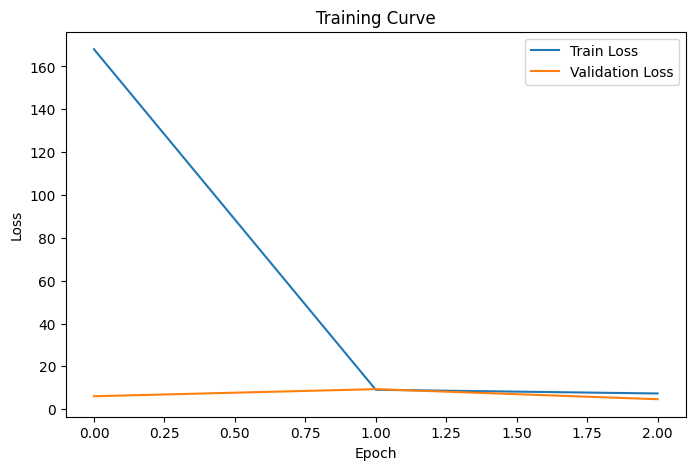

In [22]:
history = model.fit(
    [pet_features_1_train, pet_features_2_train],
    labels_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Curve')
plt.show()
